## Plot mean of each cluster, for all clusters: precip
Fig 4. Also filenames for download of other variables, and calculating sums for each event, max, surrounding gridboxes

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import math
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
from matplotlib import rcParams
import matplotlib
import ast

ERROR 1: PROJ: proj_create_from_database: Cannot find proj.db


In [2]:
rcParams['font.size'] = 20

In [3]:
#output file location
input_table_loc = '/div/nac/users/zofias/plots/XXN/prect_6_clim/single'
out_plots = '/div/nac/users/zofias/plots/XXN/paper_plots'

input_fileloc = '/div/no-backup/Large_Ensemble_data/CESM2-LENS/BSSP370smbb/PRECT'

group_label = '7_cluster_events'

var_name='PRECT'

# %%
# select region by changing region_label
region_label = 'NO_ext' #sys.argv[3] #'EU' # 'SA' 'EA' 'NA' 'EU'

regions = {'SA': [5,35,65,95],
           'EA' : [20,53,95,133],
           'NA' : [25,70,-150,-45],
           'EU' : [35,70,-20,45],
           'NO' : [53,72,0,32],
           'NO_ext': [50,75,-25,32]}

#selects lat lon bounds for region
lat_min, lat_max, lon_min, lon_max = regions[region_label]


In [4]:
locs_dataframe = pd.read_csv(f'{input_table_loc}/grouped_events_table.csv',index_col=0)

In [5]:
#extract member columns from filename
locs_dataframe['member_ind'] = pd.to_numeric(locs_dataframe['ens_member'].str[1:]) - 1

# read in disctionary of mapping from ensemble index to label
with open('/div/nac/users/zofias/XXN/ens_member_labs_dict.txt', 'r') as file:
    test = file.read()
    ens_dict = ast.literal_eval(test)

# map member index to label
locs_dataframe['member_lab'] = locs_dataframe['member_ind'].map(ens_dict)

# make column with precip filename
locs_dataframe['prectfile'] = locs_dataframe.member_lab.apply(lambda x: f"b.e21.BSSP370smbb.f09_g17.LE2-{x}.cam.h1.PRECT.20150101-21001231.nc")

#make column with correct dacade lab for file download
year_labs = ['20150101-20241231.nc','20250101-20341231.nc','20350101-20441231.nc','20450101-20541231.nc','20550101-20641231.nc','20650101-20741231.nc','20750101-20841231.nc','20850101-20941231.nc','20950101-21001231.nc']
bins = [2015, 2024, 2034, 2044, 2054, 2064, 2074, 2084, 2094,2101]
labels = year_labs
locs_dataframe['decade_lab'] = pd.cut(locs_dataframe.year, bins, labels = labels,include_lowest = True)

In [6]:
#define dates for selecting data (14 days before up to 3 days after)
locs_dataframe['start_date'] = (pd.to_datetime(locs_dataframe['date']) - pd.to_timedelta(14,'d')).dt.strftime("%Y-%m-%d") 
locs_dataframe['end_date'] = (pd.to_datetime(locs_dataframe['date']) + pd.to_timedelta(3,'d')).dt.strftime("%Y-%m-%d")

In [7]:
locs_dataframe

,filename,date,lat,lon,sigma,ens_member,type,group,pd_time,month,year,member_ind,member_lab,prectfile,decade_lab,start_date,end_date
0,PRECT5day_6_r10_2093-09-04_69.27_30.0_single.png,2093-09-04,69.27,30.00,6,r10,PRECT5day,0,2093-09-04,9,2093,9,1191.010,b.e21.BSSP370smbb.f09_g17.LE2-1191.010.cam.h1....,20850101-20941231.nc,2093-08-21,2093-09-07
1,PRECT5day_6_r11_2079-06-30_70.21_26.25_single.png,2079-06-30,70.21,26.25,6,r11,PRECT5day,0,2079-06-30,6,2079,10,1231.011,b.e21.BSSP370smbb.f09_g17.LE2-1231.011.cam.h1....,20750101-20841231.nc,2079-06-16,2079-07-03
2,PRECT5day_6_r1_2072-06-15_70.21_24.58_single.png,2072-06-15,70.21,24.58,6,r1,PRECT5day,0,2072-06-15,6,2072,0,1011.001,b.e21.BSSP370smbb.f09_g17.LE2-1011.001.cam.h1....,20650101-20741231.nc,2072-06-01,2072-06-18
3,PRECT5day_6_r12_2044-06-15_70.21_23.75_single.png,2044-06-15,70.21,23.75,6,r12,PRECT5day,0,2044-06-15,6,2044,11,1231.012,b.e21.BSSP370smbb.f09_g17.LE2-1231.012.cam.h1....,20350101-20441231.nc,2044-06-01,2044-06-18
4,PRECT5day_6_r12_2050-10-05_69.27_29.38_single.png,2050-10-05,69.27,29.38,6,r12,PRECT5day,0,2050-10-05,10,2050,11,1231.012,b.e21.BSSP370smbb.f09_g17.LE2-1231.012.cam.h1....,20450101-20541231.nc,2050-09-21,2050-10-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,PRECT5day_6_r6_2095-10-05_70.21_30.0_single.png,2095-10-05,70.21,30.00,6,r6,PRECT5day,6,2095-10-05,10,2095,5,1111.006,b.e21.BSSP370smbb.f09_g17.LE2-1111.006.cam.h1....,20950101-21001231.nc,2095-09-21,2095-10-08
470,PRECT5day_6_r7_2073-07-10_69.87_26.76_single.png,2073-07-10,69.87,26.76,6,r7,PRECT5day,6,2073-07-10,7,2073,6,1131.007,b.e21.BSSP370smbb.f09_g17.LE2-1131.007.cam.h1....,20650101-20741231.nc,2073-06-26,2073-07-13
471,PRECT5day_6_r8_2028-09-08_69.27_30.0_single.png,2028-09-08,69.27,30.00,6,r8,PRECT5day,6,2028-09-08,9,2028,7,1151.008,b.e21.BSSP370smbb.f09_g17.LE2-1151.008.cam.h1....,20250101-20341231.nc,2028-08-25,2028-09-11
472,PRECT5day_6_r8_2082-11-01_69.27_25.31_single.png,2082-11-01,69.27,25.31,6,r8,PRECT5day,6,2082-11-01,11,2082,7,1151.008,b.e21.BSSP370smbb.f09_g17.LE2-1151.008.cam.h1....,20750101-20841231.nc,2082-10-18,2082-11-04


In [8]:
#make lat and lon bins over select region (for selecting 9 gridboxes for each event)
# got event lat and lons from CESM2LENS nc file, lats have loads of decimals so rounded to 2dp here (same as in selection below)
lon_bins = [-25.,-23.75,-22.5,-21.25,-20.,-18.75,-17.5,-16.25,-15.,-13.75,-12.5,-11.25,-10.,-8.75,-7.5,-6.25,-5.,-3.75,-2.5 ,-1.25,0.,1.25,2.5,3.75,5.,6.25,7.5,8.75,10.,11.25,12.5,13.75,15.,16.25,17.5,18.75,20.,21.25,22.5,23.75,25.,26.25,27.5,28.75,30.,31.25]
locs_dataframe['lon_bin'] = pd.cut(locs_dataframe.lon, lon_bins, labels = lon_bins[:-1],include_lowest = True)
locs_dataframe['lon_min'] = locs_dataframe.lon_bin.apply(lambda x: x - 1.25)
locs_dataframe['lon_max'] = locs_dataframe.lon_bin.apply(lambda x: x + 1.25)

lat_bins = [49.48,  50.42,  51.36,  52.3 ,
        53.25,  54.19,  55.13,  56.07,  57.02,  57.96,  58.9 ,  59.84,
        60.79,  61.73,  62.67,  63.61,  64.55,  65.5 ,  66.44,  67.38,
        68.32,  69.27,  70.21,  71.15,  72.09,  73.04,  73.98,  74.92,
        75.86,  76.81,  77.75,  78.69,  79.63] #one extra on either end for making min and max

locs_dataframe['lat_bin'] = pd.cut(locs_dataframe.lat, lat_bins[1:-1],labels=lat_bins[1:-2],include_lowest = True)
locs_dataframe['lat_min'] = pd.cut(locs_dataframe.lat, lat_bins[1:-1],labels=lat_bins[0:-3],include_lowest = True)
locs_dataframe['lat_max'] = pd.cut(locs_dataframe.lat, lat_bins[1:-1],labels=lat_bins[2:-1],include_lowest = True)

In [9]:
# build concatenated dataset for each cluster
def load_cluster_events(cluster_df):
    event_datasets = []

    for i, row in cluster_df.reset_index(drop=True).iterrows():
        print(f"Processing {i+1} of {len(cluster_df)}")
        #print(row["start_date"])

        ds = xr.open_dataset(f"{input_fileloc}/{row['prectfile']}",
                             decode_times=True).sel(time=slice(row["start_date"], row["end_date"]))
        
        ds = ds.drop_vars("time_bnds", errors="ignore")

        #reset lon coord
        ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby("lon")
        #select region
        ds = ds.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))

        #reindex time to be -14 to 3 for all events (some have 17 time steps, some have 18)
        n = ds.sizes["time"]                       # can be 17 or 18
        ds = ds.assign_coords(time=np.arange(-14, -14 + n))
        ds = ds.reindex(time=np.arange(-14, 4)) 

        event_datasets.append(ds)

    # member = event index within this cluster
    return xr.concat(event_datasets, dim="member")

In [10]:
#make dictionary for all cluster datasets
cluster_data = {}  

for g in range(7):
    print(f'Processing cluster {g+1} of 7')
    cluster_df = locs_dataframe[locs_dataframe["group"] == g]#[:8]
    cluster_data[g] = load_cluster_events(cluster_df)

Processing cluster 1 of 7
Processing 1 of 109
Processing 2 of 109
Processing 3 of 109
Processing 4 of 109
Processing 5 of 109
Processing 6 of 109
Processing 7 of 109
Processing 8 of 109
Processing 9 of 109
Processing 10 of 109
Processing 11 of 109
Processing 12 of 109
Processing 13 of 109
Processing 14 of 109
Processing 15 of 109
Processing 16 of 109
Processing 17 of 109
Processing 18 of 109
Processing 19 of 109
Processing 20 of 109
Processing 21 of 109
Processing 22 of 109
Processing 23 of 109
Processing 24 of 109
Processing 25 of 109
Processing 26 of 109
Processing 27 of 109
Processing 28 of 109
Processing 29 of 109
Processing 30 of 109
Processing 31 of 109
Processing 32 of 109
Processing 33 of 109
Processing 34 of 109
Processing 35 of 109
Processing 36 of 109
Processing 37 of 109
Processing 38 of 109
Processing 39 of 109
Processing 40 of 109
Processing 41 of 109
Processing 42 of 109
Processing 43 of 109
Processing 44 of 109
Processing 45 of 109
Processing 46 of 109
Processing 47 of 

### Plot precip event day

Text(0.5, 1, 'Cluster 1')

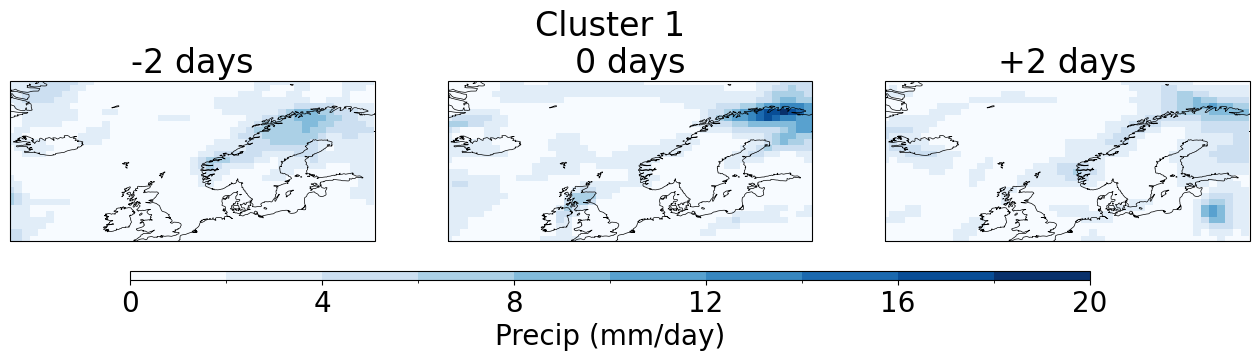

In [11]:
#testing for one cluster
fig, axs = plt.subplots(nrows=1,ncols=3,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(16,3)
                       )
    # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()#Loop over all of the models

fg = (cluster_data[0]['PRECT']*8.64e7).isel(time=12).mean(dim='member').plot(ax=axs[0],cmap='Blues',add_colorbar=False,levels=11,#,norm=norm, #
                                                vmax=20, vmin=0, 
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[0].add_patch(circle2)
axs[0].set_title(f'-2 days')
axs[0].coastlines(linewidth=0.5)  # cartopy function


fg = (cluster_data[0]['PRECT']*8.64e7).isel(time=14).mean(dim='member').plot(ax=axs[1],cmap='Blues',levels=11,#,norm=norm, #
                                                vmax=20, vmin=0, 
                                                add_colorbar=False,
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[4].add_patch(circle3)
axs[1].set_title(f'0 days')
axs[1].coastlines(linewidth=0.5)  # cartopy function


fg = (cluster_data[0]['PRECT']*8.64e7).isel(time=16).mean(dim='member').plot(ax=axs[2],cmap='Blues',add_colorbar=False,levels=11,#,norm=norm, #
                                                vmax=20, vmin=0, 
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[5].add_patch(circle4)
axs[2].set_title(f'+2 days')
axs[2].coastlines(linewidth=0.5)  # cartopy function

cbar_ax = fig.add_axes([0.2, 0.1, 0.6, 0.03])
cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')

plt.suptitle(f'Cluster 1',y=1)
#fig.subplots_adjust(bottom=0.2, top=0.95, left=0.1, right=0.9,wspace=0.2, hspace=0.17)
    #fig.savefig(f'{out_plots}/{fig_labs[n]}_event_summary.pdf', format='pdf', bbox_inches='tight')

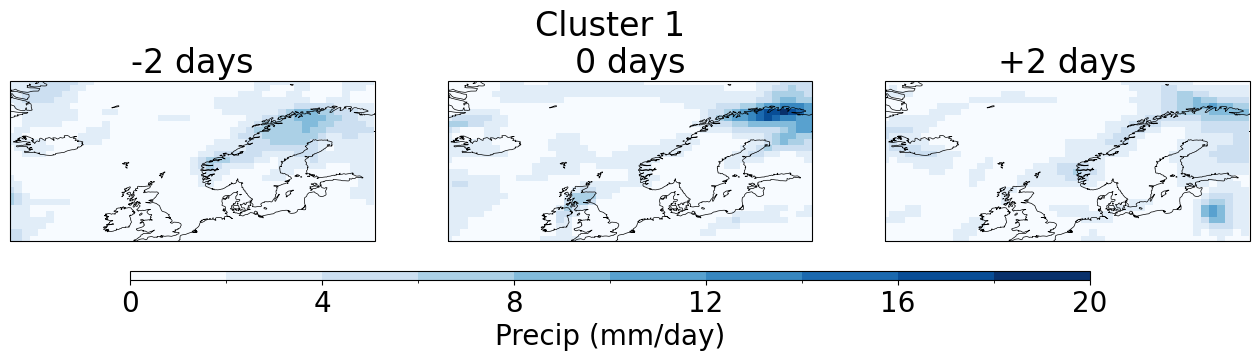

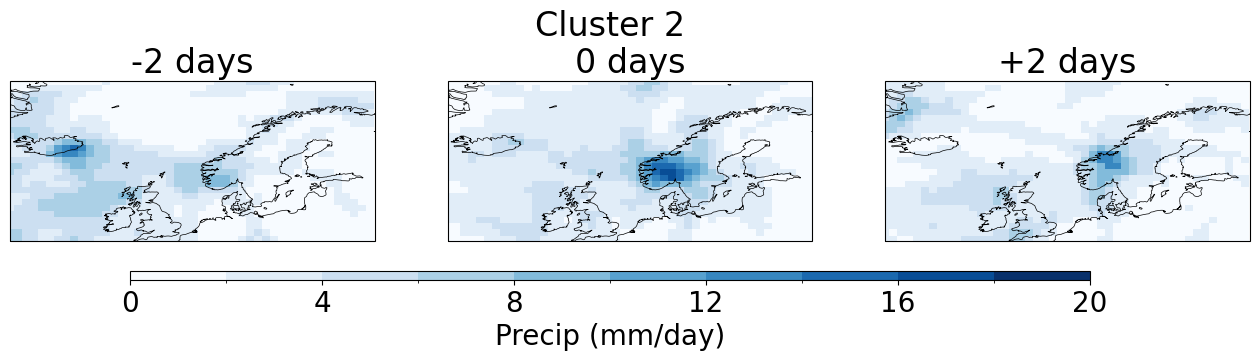

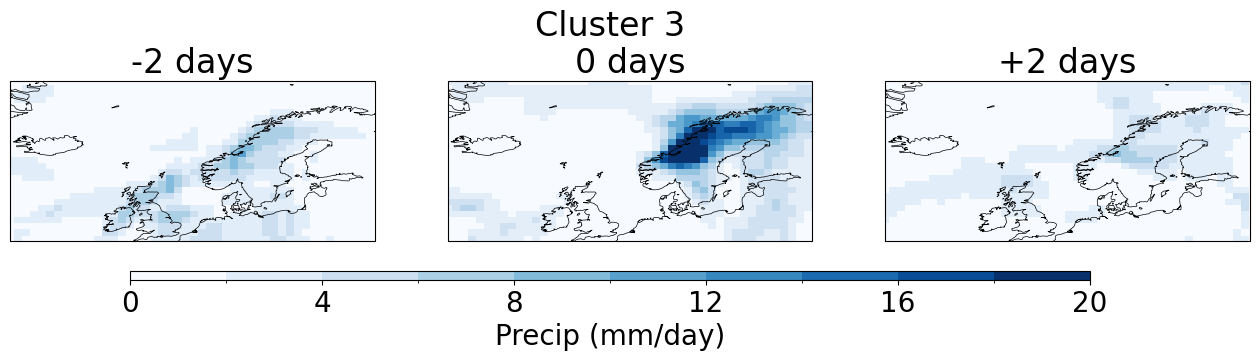

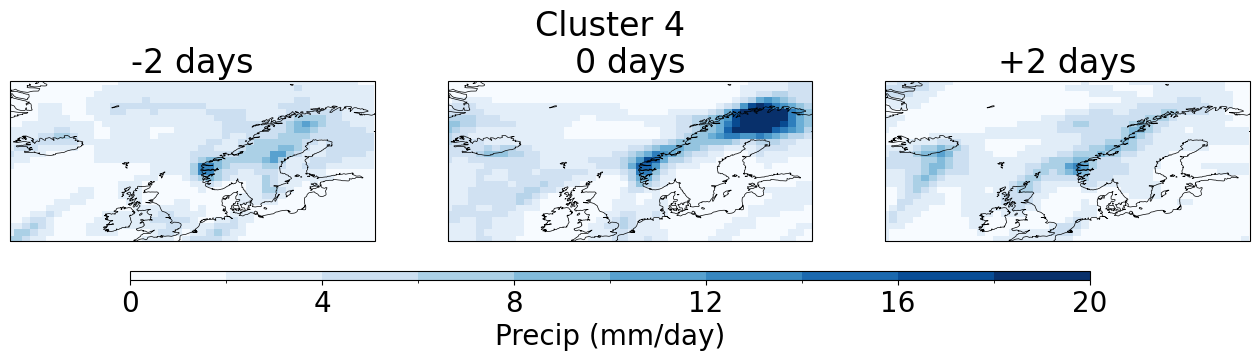

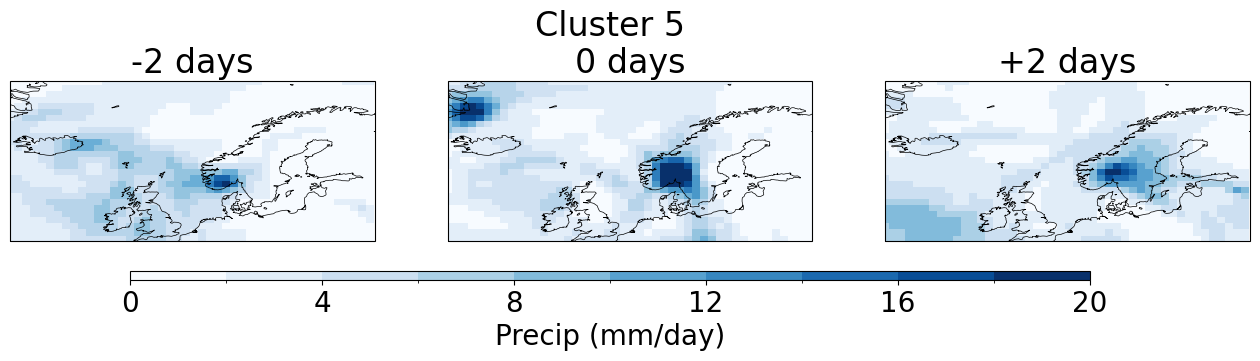

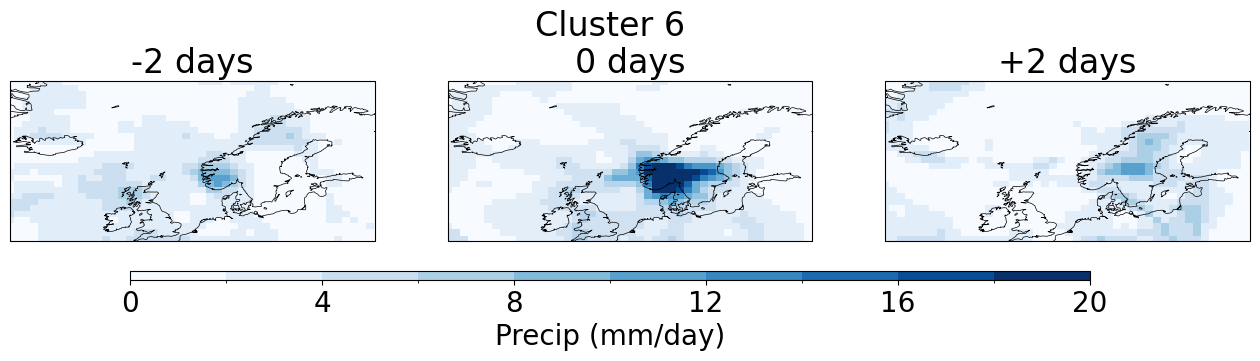

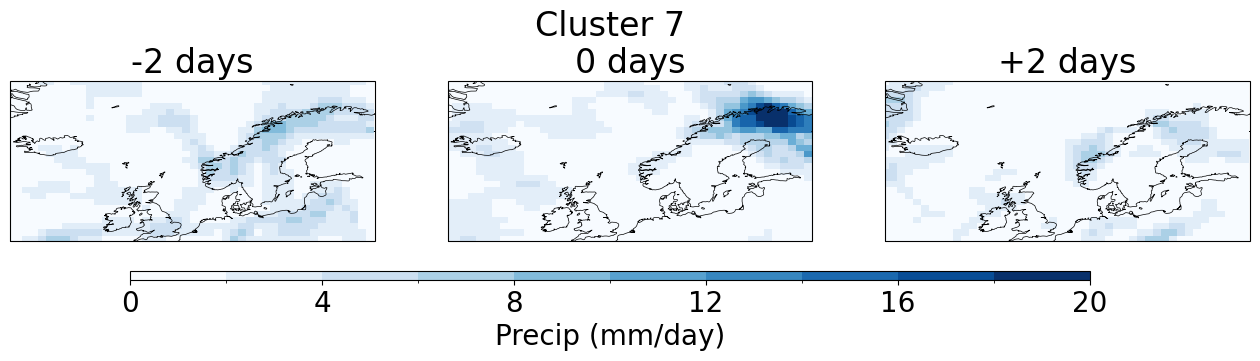

In [12]:
for n,time in enumerate(cluster_data):
    # Define the figure and each axis for the 3 rows and 3 columns
    fig, axs = plt.subplots(nrows=1,ncols=3,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(16,3)
                       )
    # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
    axs=axs.flatten()#Loop over all of the models

    fg = (cluster_data[n]['PRECT']*8.64e7).isel(time=12).mean(dim='member').plot(ax=axs[0],cmap='Blues',add_colorbar=False,levels=11,#,norm=norm, #
                                                vmax=20, vmin=0, 
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[0].add_patch(circle2)
    axs[0].set_title(f'-2 days')
    axs[0].coastlines(linewidth=0.5)  # cartopy function


    fg = (cluster_data[n]['PRECT']*8.64e7).isel(time=14).mean(dim='member').plot(ax=axs[1],cmap='Blues',levels=11,#,norm=norm, #
                                                vmax=20, vmin=0, 
                                                add_colorbar=False,
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[4].add_patch(circle3)
    axs[1].set_title(f'0 days')
    axs[1].coastlines(linewidth=0.5)  # cartopy function


    fg = (cluster_data[n]['PRECT']*8.64e7).isel(time=16).mean(dim='member').plot(ax=axs[2],cmap='Blues',add_colorbar=False,levels=11,#,norm=norm, #
                                                vmax=20, vmin=0, 
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[5].add_patch(circle4)
    axs[2].set_title(f'+2 days')
    axs[2].coastlines(linewidth=0.5)  # cartopy function

    cbar_ax = fig.add_axes([0.2, 0.1, 0.6, 0.03])
    cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')

    plt.suptitle(f'Cluster {n+1}',y=1)
#fig.subplots_adjust(bottom=0.2, top=0.95, left=0.1, right=0.9,wspace=0.2, hspace=0.17)
    #fig.savefig(f'{out_plots}/{fig_labs[n]}_event_summary.pdf', format='pdf', bbox_inches='tight')

/scratch/tmp/ipykernel_660396/1215518881.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1)


Text(0.07, 0.225, 'Precip (mm/day)')

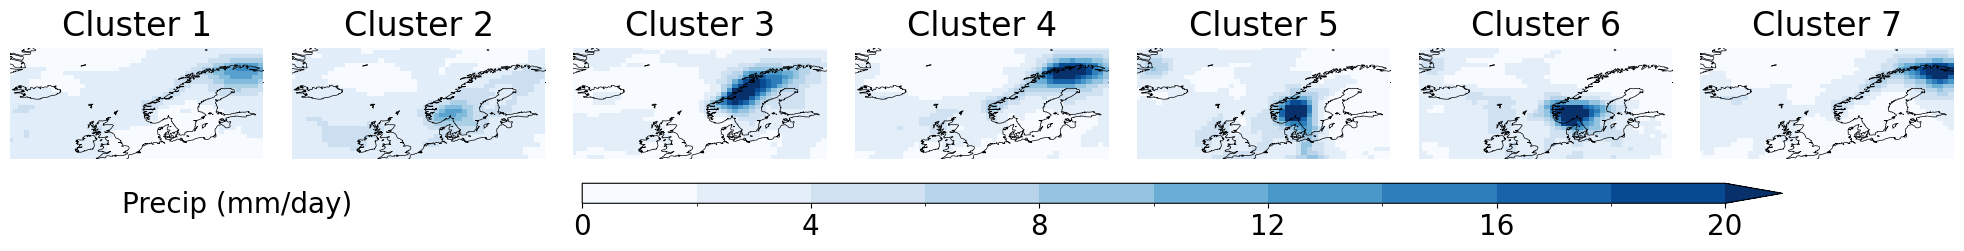

In [15]:
fig, axs = plt.subplots(nrows=1,ncols=len(cluster_data),
                        subplot_kw={'projection': ccrs.PlateCarree(),'frameon':False},
                        figsize=(20,4),
                        frameon=False
                        )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()

#Loop over all of the models
for n,time in enumerate(cluster_data):
    fg = (cluster_data[n]['PRECT']*8.64e7).isel(time=14).mean(dim='member').plot(ax=axs[n],cmap='Blues',levels=11,#,norm=norm, #
                                                vmax=20, vmin=0,  
                                                add_colorbar=False,
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[4].add_patch(circle3)
    axs[n].set_title(f'0 days')
    axs[n].coastlines(linewidth=0.5)  # cartopy function
    axs[n].set_title(f'Cluster {n+1}',y=1.03)


cbar_ax = fig.add_axes([0.3, 0.25, 0.6, 0.05])
cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='')

#cbar_ax = fig.add_axes([0.2, 0.47, 0.6, 0.015])
#cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')
#plt.suptitle(f'Locations of grouped {exp_label} extremes',y=0.88)
#fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.02, hspace=0.17)
plt.tight_layout(pad=1)
fig.text(0.07,0.225,f'Precip (mm/day)')

/scratch/tmp/ipykernel_660396/350557560.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.5)


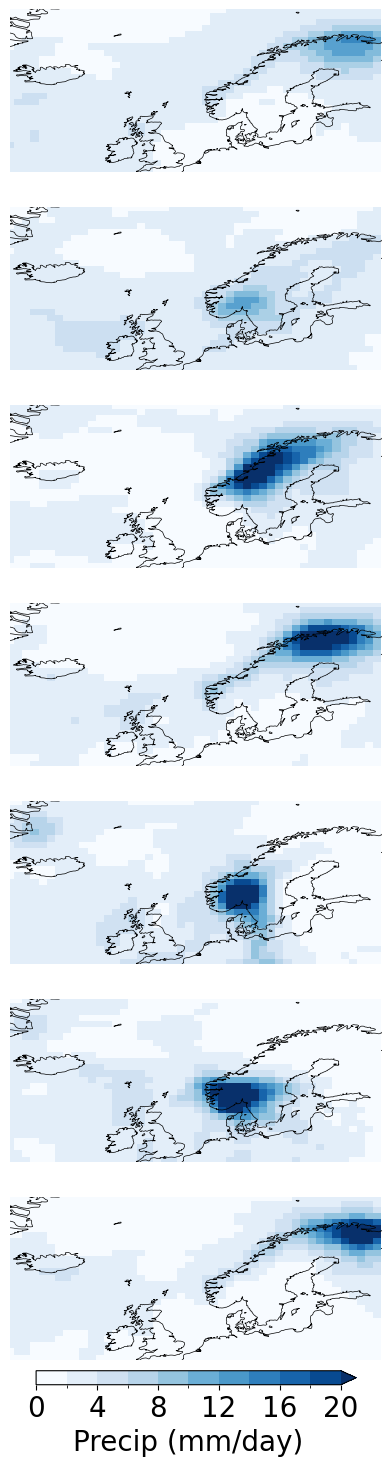

In [14]:
fig, axs = plt.subplots(nrows=len(cluster_data),ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree(),'frameon':False},
                        figsize=(4,14),
                        frameon=False
                        )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()

#Loop over all of the models
for n,time in enumerate(cluster_data):
    fg = (cluster_data[n]['PRECT']*8.64e7).isel(time=14).mean(dim='member').plot(ax=axs[n],cmap='Blues',levels=11,#,norm=norm, #
                                                vmax=20, vmin=0,  
                                                add_colorbar=False,
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    axs[n].coastlines(linewidth=0.5)  # cartopy function
    axs[n].set_title('')#(f'Cluster {n+1}',y=1.03)
    


cbar_ax = fig.add_axes([0.1, 0.0, 0.8, 0.01])
cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')

#cbar_ax = fig.add_axes([0.2, 0.47, 0.6, 0.015])
#cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')
#plt.suptitle(f'Locations of grouped {exp_label} extremes',y=0.88)
#fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.02, hspace=0.17)
plt.tight_layout(pad=0.5)
#fig.text(0.07,0.225,f'Precip (mm/day)')

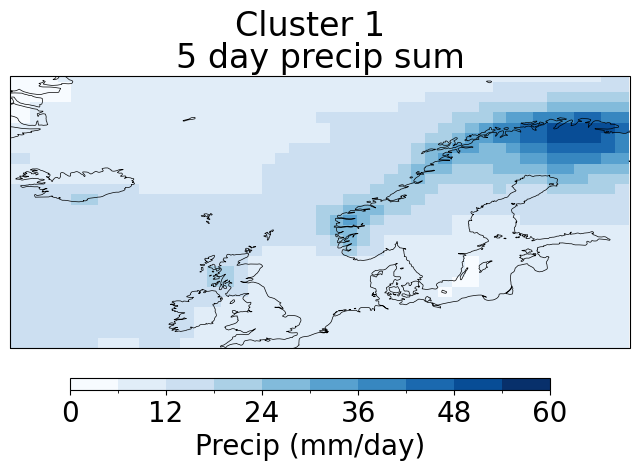

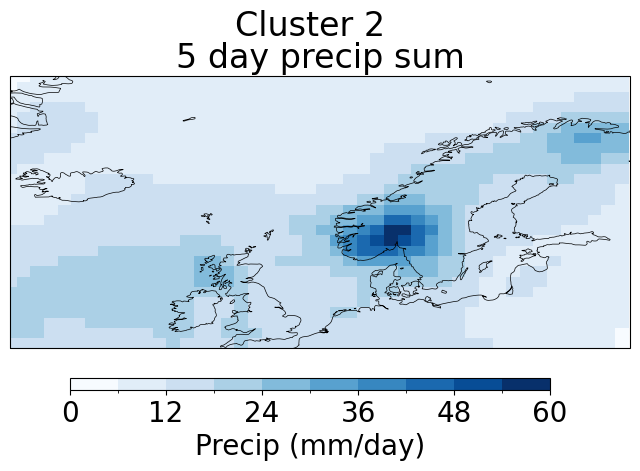

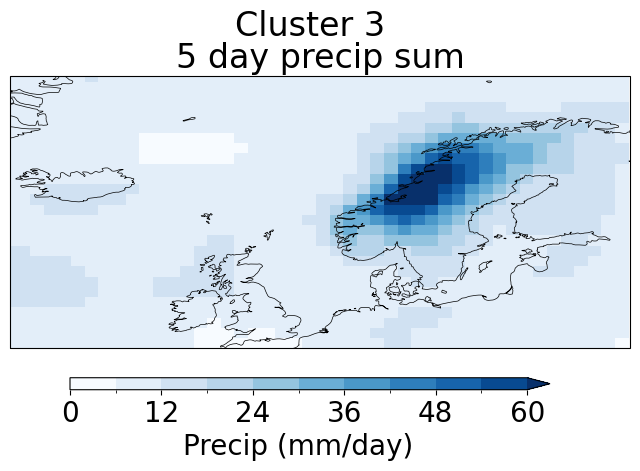

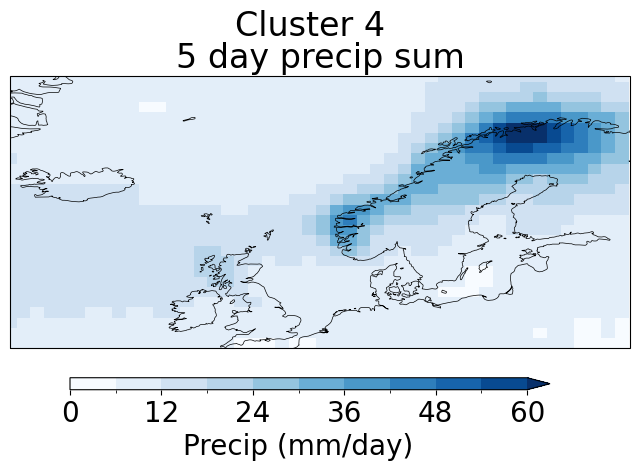

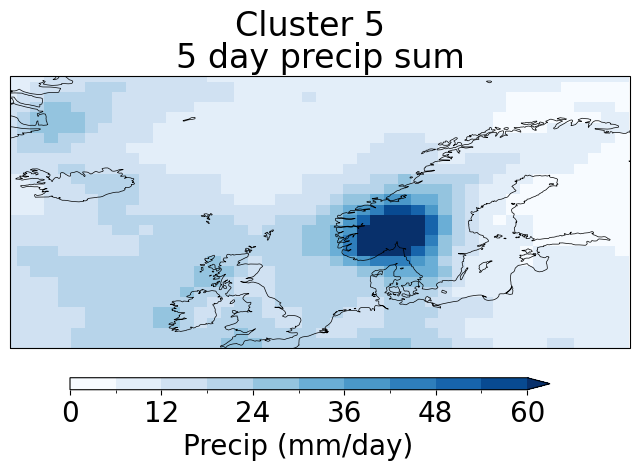

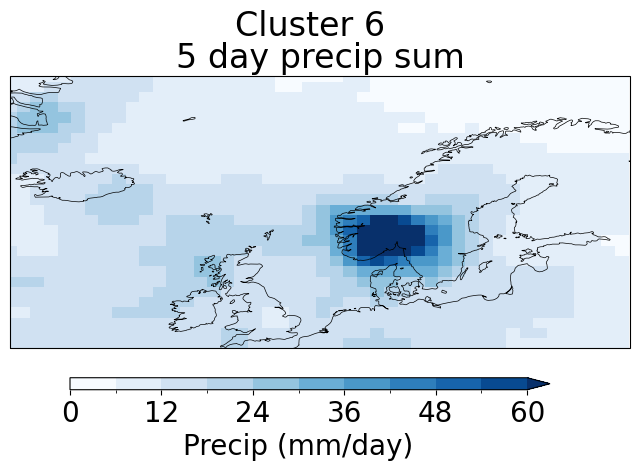

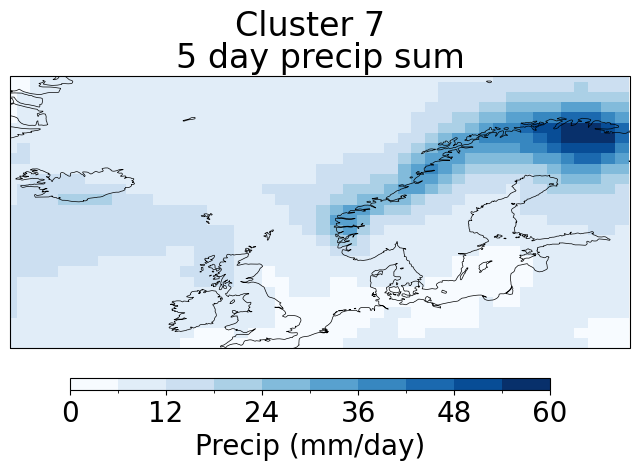

In [ ]:
#Rx5day
for n,time in enumerate(cluster_data):
    # Define the figure and each axis for the 3 rows and 3 columns
    fig, axs = plt.subplots(nrows=1,ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(8,4)
                       )
    # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
    #axs=axs.flatten()#Loop over all of the models

    fg = (cluster_data[n]['PRECT']*8.64e7).isel(time=slice(12,17)).sum(dim='time').mean(dim='member').plot(ax=axs,cmap='Blues',add_colorbar=False,levels=11,#,norm=norm, #
                                                vmax=60, vmin=0, 
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[0].add_patch(circle2)
    axs.set_title(f'5 day precip sum')
    axs.coastlines(linewidth=0.5)  # cartopy function

    cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.03])
    cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')

    plt.suptitle(f'Cluster {n+1}',y=1)
#fig.subplots_adjust(bottom=0.2, top=0.95, left=0.1, right=0.9,wspace=0.2, hspace=0.17)
    #fig.savefig(f'{out_plots}/{fig_labs[n]}_event_summary.pdf', format='pdf', bbox_inches='tight')

## Generate file names for clusters weather data download

In [13]:
# ****** Select vars here ********
vars = ['U850','V850','PSL','OMEGA500']
loc = 'https://osdf-data.gdex.ucar.edu/ncar/gdex/d651056/CESM2-LE/atm/proc/tseries/day_1/'
filelist = []

for g in range(7):
    print(f'Processing cluster {g+1} of 7')
    cluster_df = locs_dataframe[locs_dataframe["group"] == g][:8]
    cluster_data[g] = load_cluster_events(cluster_df)
    for n,var in enumerate(vars):
        for index, row in cluster_df.iterrows():
            filename = f"{loc}{var}/b.e21.BSSP370smbb.f09_g17.LE2-{row['member_lab']}.cam.h1.{var}.{row['decade_lab']}"
            filelist.append(filename)
print(filelist)

Processing cluster 1 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 2 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 3 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 4 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 5 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 6 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 

In [24]:
filelist

['https://osdf-data.gdex.ucar.edu/ncar/gdex/d651056/CESM2-LE/atm/proc/tseries/day_1/U850/b.e21.BSSP370smbb.f09_g17.LE2-1191.010.cam.h1.U850.20850101-20941231.nc',
 'https://osdf-data.gdex.ucar.edu/ncar/gdex/d651056/CESM2-LE/atm/proc/tseries/day_1/U850/b.e21.BSSP370smbb.f09_g17.LE2-1231.011.cam.h1.U850.20750101-20841231.nc',
 'https://osdf-data.gdex.ucar.edu/ncar/gdex/d651056/CESM2-LE/atm/proc/tseries/day_1/U850/b.e21.BSSP370smbb.f09_g17.LE2-1011.001.cam.h1.U850.20650101-20741231.nc',
 'https://osdf-data.gdex.ucar.edu/ncar/gdex/d651056/CESM2-LE/atm/proc/tseries/day_1/U850/b.e21.BSSP370smbb.f09_g17.LE2-1231.012.cam.h1.U850.20350101-20441231.nc',
 'https://osdf-data.gdex.ucar.edu/ncar/gdex/d651056/CESM2-LE/atm/proc/tseries/day_1/U850/b.e21.BSSP370smbb.f09_g17.LE2-1231.012.cam.h1.U850.20450101-20541231.nc',
 'https://osdf-data.gdex.ucar.edu/ncar/gdex/d651056/CESM2-LE/atm/proc/tseries/day_1/U850/b.e21.BSSP370smbb.f09_g17.LE2-1231.012.cam.h1.U850.20750101-20841231.nc',
 'https://osdf-data.gd

In [25]:
#save file list
np.save('/div/nac/users/zofias/XXN/filelist_to_read_cesm2lens_7clusterbackground.npy',filelist)

## Select 9 gridboxes around event location

In [11]:
# build concatenated dataset for each cluster
def load_cluster_events_gridbox(cluster_df):
    event_datasets = []

    for i, row in cluster_df.reset_index(drop=True).iterrows():
        print(f"Processing {i+1} of {len(cluster_df)}")
        #print(row["start_date"])

        ds = xr.open_dataset(f"{input_fileloc}/{row['prectfile']}",
                             decode_times=True).sel(time=slice(row["start_date"], row["end_date"]))
        
        ds = ds.drop_vars("time_bnds", errors="ignore")

        #reset lon coord
        ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby("lon")
        # round latitudes to make them 2dp
        ds = ds.assign_coords(lat=np.round(ds.lat, 2))
        #select region
        ds = ds.sel(lon=slice(row["lon_min"], row["lon_max"]), lat=slice(row["lat_min"], row["lat_max"]))

        #reindex time to be -14 to 3 for all events (some have 17 time steps, some have 18)
        n = ds.sizes["time"]                       # can be 17 or 18
        ds = ds.assign_coords(time=np.arange(-14, -14 + n))
        ds = ds.reindex(time=np.arange(-14, 4)) 

        #reindex lat and lon from -1 to 1 for all events
        ds = ds.assign_coords(lon=np.arange(-1, 2))
        ds = ds.assign_coords(lat=np.arange(-1, 2))
        event_datasets.append(ds)

    # member = event index within this cluster
    return xr.concat(event_datasets, dim="member")

In [12]:
#make dictionary for all cluster datasets
cluster_data_9gridbox = {}  

for g in range(7):
    print(f'Processing cluster {g+1} of 7')
    cluster_df = locs_dataframe[locs_dataframe["group"] == g]
    cluster_data_9gridbox[g] = load_cluster_events_gridbox(cluster_df)

Processing cluster 1 of 7
Processing 1 of 109
Processing 2 of 109
Processing 3 of 109
Processing 4 of 109
Processing 5 of 109
Processing 6 of 109
Processing 7 of 109
Processing 8 of 109
Processing 9 of 109
Processing 10 of 109
Processing 11 of 109
Processing 12 of 109
Processing 13 of 109
Processing 14 of 109
Processing 15 of 109
Processing 16 of 109
Processing 17 of 109
Processing 18 of 109
Processing 19 of 109
Processing 20 of 109
Processing 21 of 109
Processing 22 of 109
Processing 23 of 109
Processing 24 of 109
Processing 25 of 109
Processing 26 of 109
Processing 27 of 109
Processing 28 of 109
Processing 29 of 109
Processing 30 of 109
Processing 31 of 109
Processing 32 of 109
Processing 33 of 109
Processing 34 of 109
Processing 35 of 109
Processing 36 of 109
Processing 37 of 109
Processing 38 of 109
Processing 39 of 109
Processing 40 of 109
Processing 41 of 109
Processing 42 of 109
Processing 43 of 109
Processing 44 of 109
Processing 45 of 109
Processing 46 of 109
Processing 47 of 

In [13]:
#convert to mm/day and calculate 5 day mean and sum
for n in range(7):
    cluster_data_9gridbox[n]['prect_5day_mean'] = (cluster_data_9gridbox[n].PRECT*8.64e7).mean(dim='time')
    cluster_data_9gridbox[n]['prect_5day_sum'] = (cluster_data_9gridbox[n].PRECT*8.64e7).sum(dim='time')
    cluster_data_9gridbox[n]['prect_5day_sum_max'] = cluster_data_9gridbox[n]['prect_5day_sum'].max(dim=['lat','lon'])
    cluster_data_9gridbox[n]['prect_5day_mean_max'] = cluster_data_9gridbox[n]['prect_5day_mean'].max(dim=['lat','lon'])
    cluster_data_9gridbox[n]['prect_5day_9grid_sum'] = cluster_data_9gridbox[n]['prect_5day_sum'].sum(dim=['lat','lon'])
    cluster_data_9gridbox[n]['prect_5day_9grid_mean'] = cluster_data_9gridbox[n]['prect_5day_mean'].mean(dim=['lat','lon'])
    cluster_data_9gridbox[n]['prect_5day_9grid_sum_membermean'] = cluster_data_9gridbox[n]['prect_5day_9grid_sum'].mean(dim=['member'])
    cluster_data_9gridbox[n]['prect_5day_9grid_mean_membermean'] = cluster_data_9gridbox[n]['prect_5day_9grid_mean'].mean(dim=['member'])
    cluster_data_9gridbox[n]['prect_5day_sum_max_membermean'] = cluster_data_9gridbox[n]['prect_5day_sum_max'].mean(dim=['member'])
    cluster_data_9gridbox[n]['prect_5day_mean_max_membermean'] = cluster_data_9gridbox[n]['prect_5day_mean_max'].mean(dim=['member'])


In [14]:
cluster_data_9gridbox[1]

<xarray.Dataset>
Dimensions:                           (time: 18, lat: 3, lon: 3, member: 83)
Coordinates:
  * time                              (time) int64 -14 -13 -12 -11 ... 0 1 2 3
  * lat                               (lat) int64 -1 0 1
  * lon                               (lon) int64 -1 0 1
Dimensions without coordinates: member
Data variables: (12/23)
    gw                                (member, lat) float64 0.007791 ... 0.00...
    date                              (member, time) int32 20700618 ... 20490916
    datesec                           (member, time) int32 0 0 0 0 0 ... 0 0 0 0
    ndcur                             (member, time) int32 20243 20244 ... 12668
    nscur                             (member, time) int32 0 0 0 0 0 ... 0 0 0 0
    co2vmr                            (member, time) float64 0.0006513 ... 0....
    ...                                ...
    prect_5day_9grid_sum              (member) float32 1.263e+03 ... 919.1
    prect_5day_9grid_mean             (member) float32 7.798 8.322 ... 5.673
    prect_5day_9grid_sum_membermean   float32 1.079e+03
    prect_5day_9grid_mean_membermean  float32 6.66
    prect_5day_sum_max_membermean     float32 153.4
    prect_5day_mean_max_membermean    float32 8.52
Attributes:
    CDI:               Climate Data Interface version 2.1.1 (https://mpimet.m...
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e21.BSSP370smbb.f09_g17.LE2-1191.010
    logname:           sunseon
    host:              mom1
    initial_file:      b.e21.BHISTsmbb.f09_g17.LE2-1191.010.cam.i.2015-01-01-...
    topography_file:   /mnt/lustre/share/CESM/cesm_input/atm/cam/topo/fv_0.9x...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1
    history:           Wed Jun 18 09:45:11 2025: cdo mergetime b.e21.BSSP370s...
    CDO:               Climate Data Operators version 2.1.1 (https://mpimet.m...

In [15]:
[cluster_data_9gridbox[n]['prect_5day_9grid_mean_membermean'].values for n in range(7)]

[array(5.694625, dtype=float32),
 array(6.6597776, dtype=float32),
 array(7.67105, dtype=float32),
 array(6.377598, dtype=float32),
 array(8.089262, dtype=float32),
 array(6.875587, dtype=float32),
 array(6.893645, dtype=float32)]

In [16]:
[cluster_data_9gridbox[n]['prect_5day_9grid_mean'].std(dim='member').values for n in range(7)]

[array(1.75185096),
 array(1.8727138),
 array(3.11203718),
 array(1.42303574),
 array(1.92563045),
 array(1.65147746),
 array(2.66630936)]

In [17]:
my_cmap = plt.get_cmap("Dark2", 9)  # Get the "Dark2" colormap with 7 discrete colors

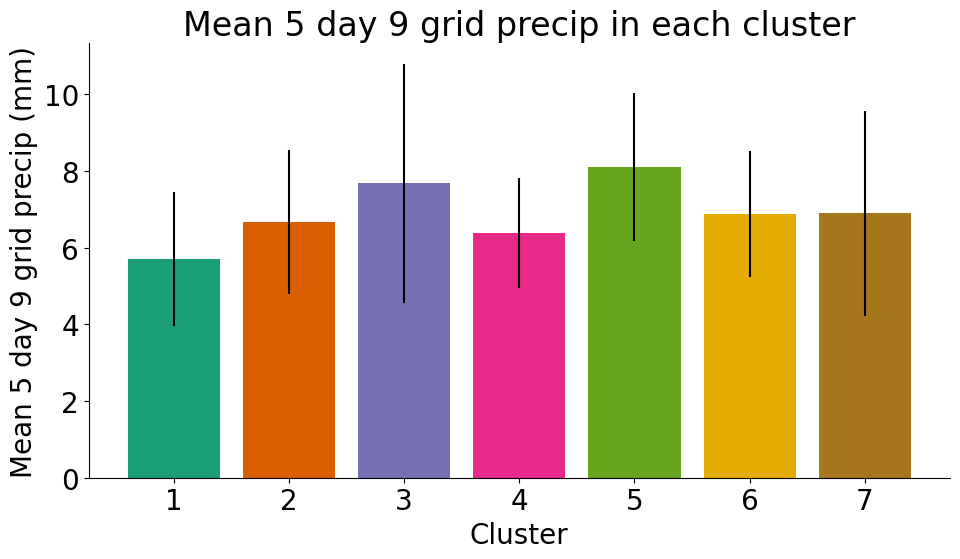

In [18]:
# Mean precip in each cluster (over all gridboxes and members)

group_data = [cluster_data_9gridbox[n]['prect_5day_9grid_mean_membermean'].values for n in range(7)]
std = [cluster_data_9gridbox[n]['prect_5day_9grid_mean'].std(dim='member').values for n in range(7)]


group_names = np.arange(1,8)
n_groups = len(group_names)
x = np.arange(n_groups)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x, group_data, yerr=std, color=my_cmap.colors, label = 'Mean 5 day 9 grid precip')


ax.set_xticks(x)
ax.set_xticklabels(group_names)
#ax.set_ylim(-0.16,0.01)
ax.set_ylabel('Mean 5 day 9 grid precip (mm)')
ax.set_xlabel('Cluster')
ax.set_title('Mean 5 day 9 grid precip in each cluster')
#ax.legend(fontsize=16,frameon=True)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()

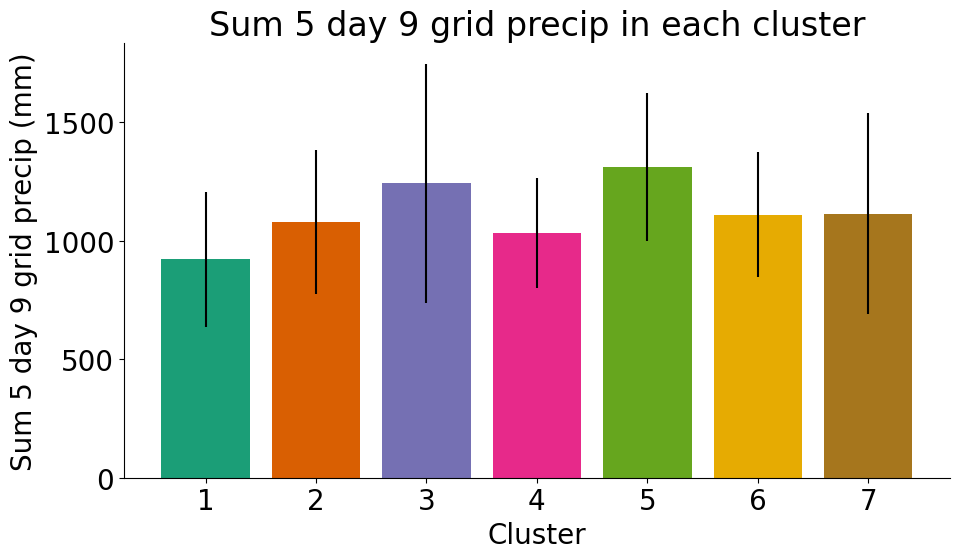

In [19]:
# Mean precip in each cluster (over all gridboxes and members)

group_data = [cluster_data_9gridbox[n]['prect_5day_9grid_sum_membermean'].values for n in range(7)]
std = [cluster_data_9gridbox[n]['prect_5day_9grid_sum'].std(dim='member').values for n in range(7)]


group_names = np.arange(1,8)
n_groups = len(group_names)
x = np.arange(n_groups)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x, group_data, yerr=std, color=my_cmap.colors,label = 'Sum 5 day 9 grid precip')


ax.set_xticks(x)
ax.set_xticklabels(group_names)
#ax.set_ylim(-0.16,0.01)
ax.set_ylabel('Sum 5 day 9 grid precip (mm)')
ax.set_xlabel('Cluster')
ax.set_title('Sum 5 day 9 grid precip in each cluster')
#ax.legend(fontsize=16,frameon=True)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()

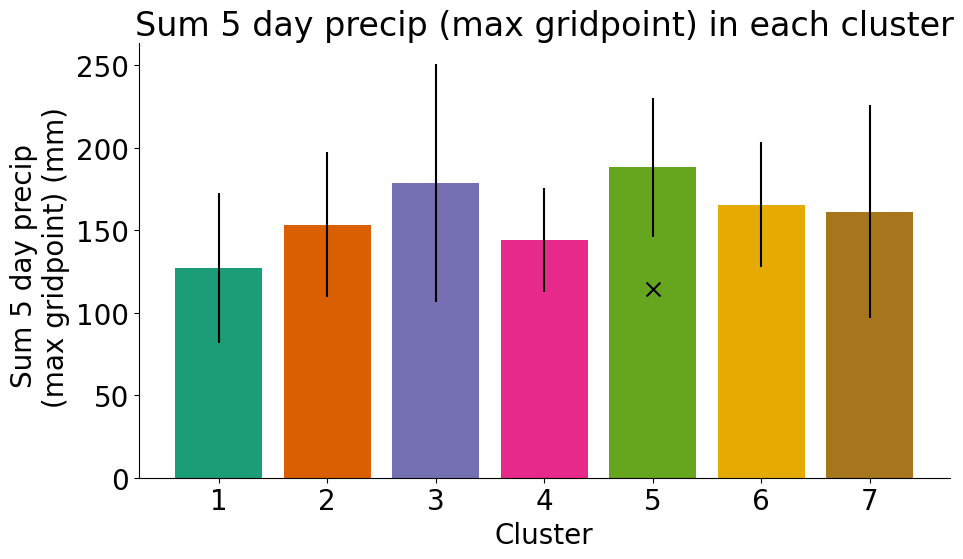

In [29]:
# Mean precip in each cluster (over all gridboxes and members)

group_data = [cluster_data_9gridbox[n]['prect_5day_sum_max_membermean'].values for n in range(7)]
std = [cluster_data_9gridbox[n]['prect_5day_sum_max'].std(dim='member').values for n in range(7)]


group_names = np.arange(1,8)
n_groups = len(group_names)
x = np.arange(n_groups)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x, group_data, yerr=std, color=my_cmap.colors, label = 'Sum 5 day precip (max gridpoint)')
ax.scatter(4,114.5,color='black',marker='x',s=100)
ax.set_xticks(x)
ax.set_xticklabels(group_names)
#ax.set_ylim(-0.16,0.01)
ax.set_ylabel('Sum 5 day precip \n (max gridpoint) (mm)')
ax.set_xlabel('Cluster')
ax.set_title('Sum 5 day precip (max gridpoint) in each cluster')
#ax.legend(fontsize=16,frameon=True)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()

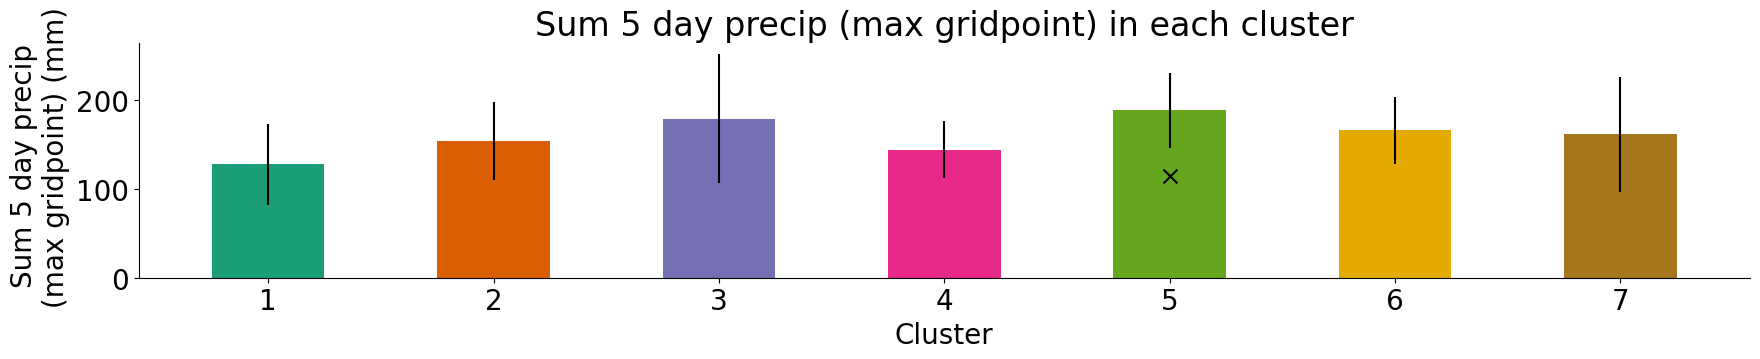

In [33]:
# Mean precip in each cluster (over all gridboxes and members)

group_data = [cluster_data_9gridbox[n]['prect_5day_sum_max_membermean'].values for n in range(7)]
std = [cluster_data_9gridbox[n]['prect_5day_sum_max'].std(dim='member').values for n in range(7)]


group_names = np.arange(1,8)
n_groups = len(group_names)
x = np.arange(n_groups)

fig, ax = plt.subplots(figsize=(18, 4))

ax.bar(x, group_data, yerr=std, color=my_cmap.colors, width = 0.5, label = 'Sum 5 day precip (max gridpoint)')
ax.scatter(4,114.5,color='black',marker='x',s=100)
ax.set_xticks(x)
ax.set_xticklabels(group_names)
#ax.set_ylim(-0.16,0.01)
ax.set_ylabel('Sum 5 day precip \n (max gridpoint) (mm)')
ax.set_xlabel('Cluster')
ax.set_title('Sum 5 day precip (max gridpoint) in each cluster')
#ax.legend(fontsize=16,frameon=True)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()

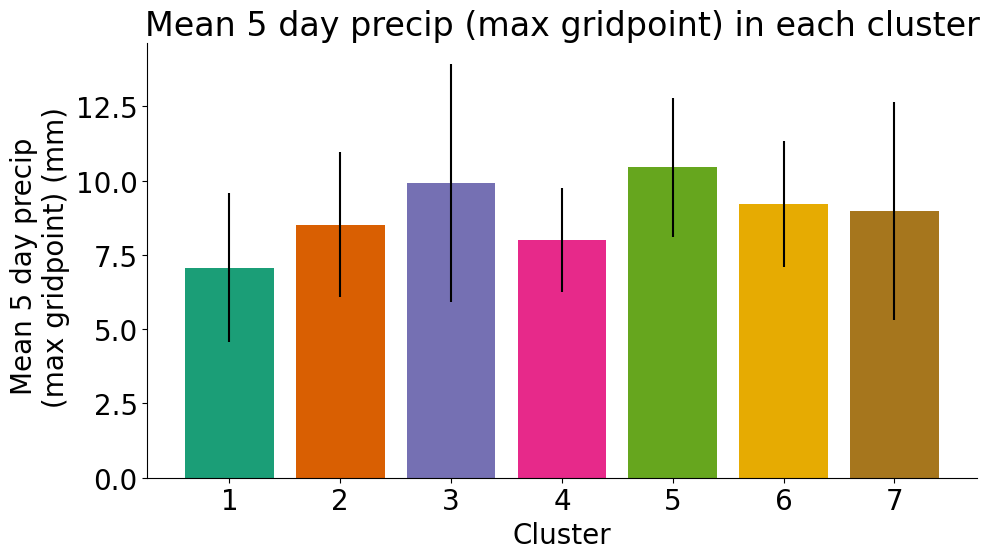

In [21]:
# Mean precip in each cluster (max gridbox)

group_data = [cluster_data_9gridbox[n]['prect_5day_mean_max_membermean'].values for n in range(7)]
std = [cluster_data_9gridbox[n]['prect_5day_mean_max'].std(dim='member').values for n in range(7)]


group_names = np.arange(1,8)
n_groups = len(group_names)
x = np.arange(n_groups)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x, group_data, yerr=std, color=my_cmap.colors, label = 'Mean 5 day precip (max gridpoint)')


ax.set_xticks(x)
ax.set_xticklabels(group_names)
#ax.set_ylim(-0.16,0.01)
ax.set_ylabel(f'Mean 5 day precip \n (max gridpoint) (mm)')
ax.set_xlabel('Cluster')
ax.set_title('Mean 5 day precip (max gridpoint) in each cluster')
#ax.legend(fontsize=16,frameon=True)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()